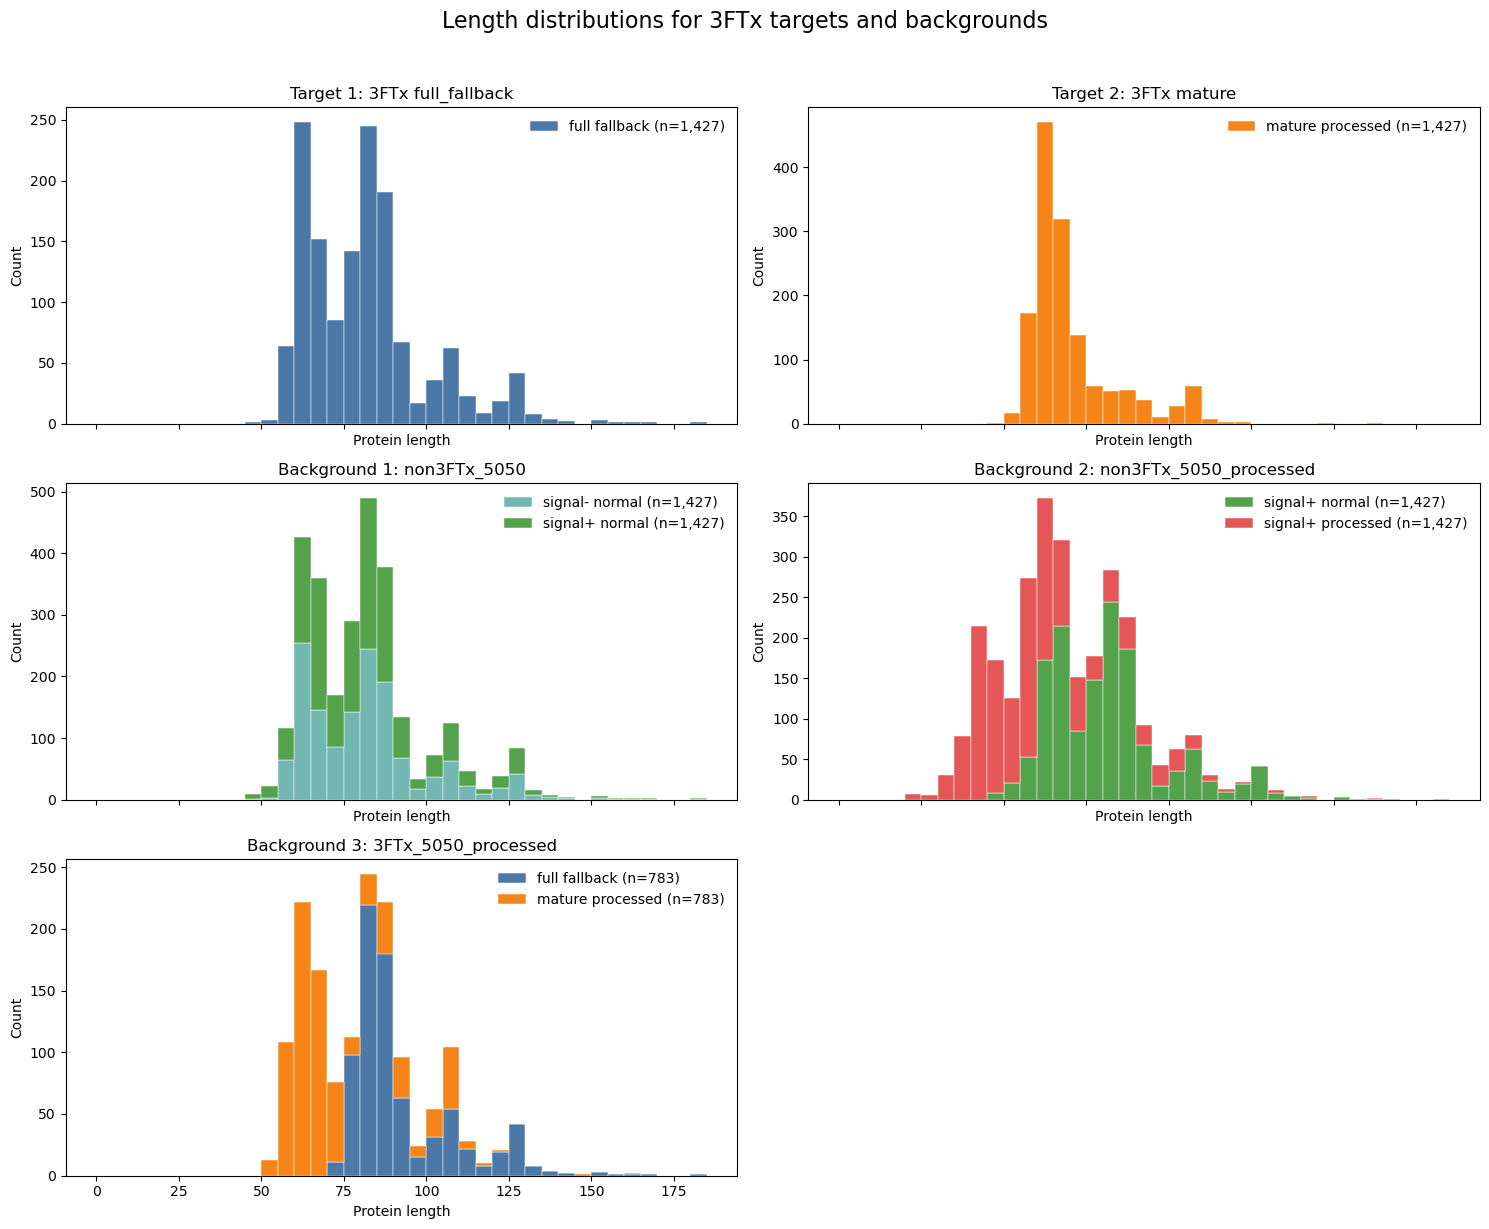

n  min  median  \
dataset                              category                               
Background 1: non3FTx_5050           signal+ normal     1427   46    80.0   
                                     signal- normal     1427   46    81.0   
Background 2: non3FTx_5050_processed signal+ normal     1427   46    80.0   
                                     signal+ processed  1427   22    58.0   
Background 3: 3FTx_5050_processed    full fallback       783   72    86.0   
                                     mature processed    783   51    65.0   
Target 1: 3FTx full_fallback         full fallback      1427   46    81.0   
Target 2: 3FTx mature                mature processed   1427   46    65.0   

                                                        mean  max  
dataset                              category                      
Background 1: non3FTx_5050           signal+ normal     81.2  184  
                                     signal- normal     81.0  184  
Background 2: non3FTx_5050_processed signal+ normal     81.2  184  
                                     signal+ processed  59.2  164  
Background 3: 3FTx_5050_processed    full fallback      92.5  184  
                                     mature processed   71.6  164  
Target 1: 3FTx full_fallback         full fallback      81.0  184  
Target 2: 3FTx mature                mature processed   69.6  164

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Works whether the notebook is launched from the repository root or PP_project/.
cwd = Path.cwd()
project_dir = cwd if (cwd / "datasets").exists() else cwd / "PP_project"
datasets_dir = project_dir / "datasets"


def read_fasta_lengths(path: Path, label: str, category: str) -> pd.DataFrame:
    rows = []
    current_entry = None
    current_length = 0

    def store_record():
        if current_entry is not None:
            rows.append(
                {
                    "entry": current_entry,
                    "length": current_length,
                    "dataset": label,
                    "category": category,
                }
            )

    with path.open(encoding="utf-8") as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue
            if line.startswith(">"):
                store_record()
                current_entry = line[1:].split(maxsplit=1)[0]
                current_length = 0
            else:
                current_length += len("".join(line.split()))
    store_record()
    return pd.DataFrame(rows)


def read_metadata_lengths(path: Path, label: str, mode: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    columns = {column.lower(): column for column in df.columns}
    entry_col = columns.get("entry")
    length_col = columns.get("length")
    if entry_col is None or length_col is None:
        raise ValueError(f"{path} must contain Entry and Length columns")

    out = df[[entry_col, length_col]].rename(
        columns={entry_col: "entry", length_col: "length"}
    )
    out["dataset"] = label
    out["length"] = pd.to_numeric(out["length"], errors="coerce")

    if mode == "signal_status":
        signal_col = columns.get("signal peptide")
        if signal_col is None:
            raise ValueError(f"{path} must contain Signal peptide for signal-status mode")
        has_signal = df[signal_col].fillna("").astype(str).str.strip().ne("")
        out["category"] = np.where(has_signal, "signal+ normal", "signal- normal")
    elif mode == "nontoxin_processed":
        out["category"] = np.where(
            out["entry"].astype(str).str.endswith("_processed"),
            "signal+ processed",
            "signal+ normal",
        )
    elif mode == "3ftx_processed":
        out["category"] = np.where(
            out["entry"].astype(str).str.endswith("_processed"),
            "mature processed",
            "full fallback",
        )
    else:
        raise ValueError(f"Unknown mode: {mode}")

    return out.dropna(subset=["length"])


datasets = [
    (
        "Target 1: 3FTx full_fallback",
        read_fasta_lengths(
            datasets_dir / "3FTx_full_fallback.fasta",
            "Target 1: 3FTx full_fallback",
            "full fallback",
        ),
    ),
    (
        "Target 2: 3FTx mature",
        read_fasta_lengths(
            datasets_dir / "3FTx_mature.fasta",
            "Target 2: 3FTx mature",
            "mature processed",
        ),
    ),
    (
        "Background 1: non3FTx_5050",
        read_metadata_lengths(
            datasets_dir / "non3FTx_5050.tsv",
            "Background 1: non3FTx_5050",
            "signal_status",
        ),
    ),
    (
        "Background 2: non3FTx_5050_processed",
        read_metadata_lengths(
            datasets_dir / "non3FTx_5050_processed.tsv",
            "Background 2: non3FTx_5050_processed",
            "nontoxin_processed",
        ),
    ),
    (
        "Background 3: 3FTx_5050_processed",
        read_metadata_lengths(
            datasets_dir / "3FTx_5050_processed.tsv",
            "Background 3: 3FTx_5050_processed",
            "3ftx_processed",
        ),
    ),
]

lengths = pd.concat([frame for _, frame in datasets], ignore_index=True)

category_order = [
    "full fallback",
    "mature processed",
    "signal- normal",
    "signal+ normal",
    "signal+ processed",
]
colors = {
    "full fallback": "#4C78A8",
    "mature processed": "#F58518",
    "signal- normal": "#72B7B2",
    "signal+ normal": "#54A24B",
    "signal+ processed": "#E45756",
}

bin_width = 5
max_length = int(np.ceil(lengths["length"].max() / bin_width) * bin_width)
bins = np.arange(0, max_length + bin_width, bin_width)

fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True, sharey=False)
axes = axes.ravel()

for ax, (label, frame) in zip(axes, datasets, strict=False):
    present_categories = [
        category for category in category_order if category in set(frame["category"])
    ]
    values = [
        frame.loc[frame["category"] == category, "length"]
        for category in present_categories
    ]

    ax.hist(
        values,
        bins=bins,
        stacked=True,
        label=[
            f"{category} (n={len(vals):,})"
            for category, vals in zip(present_categories, values, strict=False)
        ],
        color=[colors[category] for category in present_categories],
        edgecolor="white",
        linewidth=0.35,
    )
    ax.set_title(label)
    ax.set_xlabel("Protein length")
    ax.set_ylabel("Count")
    ax.legend(frameon=False)

for ax in axes[len(datasets):]:
    ax.axis("off")

fig.suptitle("Length distributions for 3FTx targets and backgrounds", y=1.02, fontsize=16)
fig.tight_layout()
plt.show()

summary = (
    lengths.groupby(["dataset", "category"], observed=True)["length"]
    .agg(n="size", min="min", median="median", mean="mean", max="max")
    .round({"median": 1, "mean": 1})
)
display(summary)
